# Assignment 4: Regularization 

**Q1.** Please answer the following questions in your own words.

1. What is the intuition of adding a penalty to mean squared error, that grows in the "size" (absolute or squared value) of the model parameters?

- Adding a penalty that grows with the size of the coefficients forces the optimizer to balance fitting the data well against keeping the model simple. Basically a model with huge coefficients can have tiny changes in input but dramatic changes in output, which is an indicator of overfitting. The penalty acts like a budget constraint where you can only spend so much on coefficient magnitude, so the model has to be more disciplined about which relationships it represents.

2. How does regularization provide a way of exploring the bias-variance trade-off?
- Increasing $\alpha$ shrinks coefficients more aggressively. More shrinkage = higher bias but lower variance. So $\alpha$ is like a knob you tune to find the right balance between underfitting and overfitting. Regularization gives you a continuous dial to move along the bias-variance curve and find the spot that minimizes test error.


3. What is the difference between LASSO and Ridge regression? How do the answers typically change for the two problems?
- Both shrink coefficients, but Ridge shrinks them toward zero while LASSO can shrink them to exactly zero. So LASSO does feature selection where it produces sparse models, while Ridge keeps all variables but dampens them.


4. How do we typically scale variables for use in regularized regression? Why?
- Standardize to mean 0, std 1. If variables are on different scales, the penalty hits large-scale variables less and small-scale variables more, which is not good. Standardizing bascially levels the playing field.


5. How is the penalty $\alpha$ typically selected?
- Cross-validation. Try a range of α values, pick the one with the lowest CV error.

6. When conducting cross validation, do you include the penalty term in evaluating the cross validated MSE? Why or why not?
- Nah, CV measures predictive accuracy on data, which has nothing to do with the penalty. The penalty is the training tool, not an error metric.

**Q2.** This is a case study on regularization.

1. Import the `cars_hw.csv` dataset. Create an `Age` variable for each vehicle. Take `Mileage_Run` and `Age`, and (a) use `PolynomialFeatures` to create a third degree expansion, (b) use `StandardScaler` to $z$-score normalize them. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV, Lasso

df = pd.read_csv("data/cars_hw.csv", index_col=0)
df["Age"] = 2024 - df["Make_Year"]
 
X_raw = df[["Mileage_Run", "Age"]].values
y = df["Price"].values
 
poly = PolynomialFeatures(degree=3, include_bias=False)
scaler = StandardScaler()
X_poly = poly.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_poly)
 
feat_names = poly.get_feature_names_out(["Mileage_Run", "Age"])

2. Use your features, run linear regression. What is the sign for the interaction between `Mileage_Run` and `Age`?


In [7]:
ols = LinearRegression().fit(X_scaled, y)
coef_df = pd.Series(ols.coef_, index=feat_names)
print("\nOLS Coefficients:\n", coef_df.round(2))
 
interaction_coef = coef_df["Mileage_Run Age"]


OLS Coefficients:
 Mileage_Run           668616.52
Age                  -184194.15
Mileage_Run^2        -149467.87
Mileage_Run Age     -1251592.34
Age^2                 215639.88
Mileage_Run^3         -65144.90
Mileage_Run^2 Age     283339.15
Mileage_Run Age^2     528082.86
Age^3                -138937.03
dtype: float64


The sign interaction between Mileage_Run and Age is negative. This means that both cars with a lot of mileage and are older lose value more steeply. 

3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(1,3,20)` to find the cost parameter)


In [9]:
alphas = np.logspace(1, 3, 20)
lasso_cv = LassoCV(alphas=alphas, cv=20, max_iter=10000).fit(X_scaled, y)
print(f"\nBest alpha: {lasso_cv.alpha_:.4f}")


Best alpha: 483.2930



4. Plot the cross-validated MSE by $\alpha$.


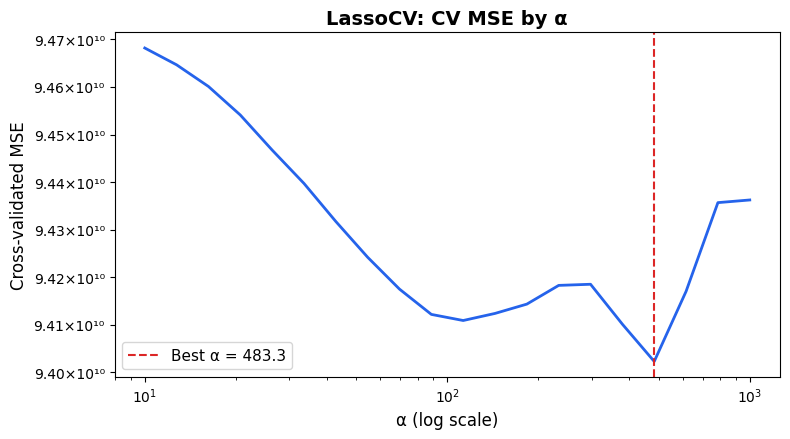

In [10]:
mse_path = np.mean(lasso_cv.mse_path_, axis=1)
 
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(lasso_cv.alphas_, mse_path, color="#2563eb", linewidth=2)
ax.axvline(lasso_cv.alpha_, color="#dc2626", linestyle="--", linewidth=1.5,
           label=f"Best α = {lasso_cv.alpha_:.1f}")
ax.set_xscale("log")
ax.set_xlabel("α (log scale)", fontsize=12)
ax.set_ylabel("Cross-validated MSE", fontsize=12)
ax.set_title("LassoCV: CV MSE by α", fontsize=14, fontweight="bold")
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e10:.2f}×10¹⁰"))
plt.tight_layout()
plt.savefig("cv_mse.png", dpi=150)
plt.show()

5. Plot the coefficient paths by $\alpha$.


/opt/homebrew/Caskroom/miniconda/base/envs/ds2002/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.408e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/Caskroom/miniconda/base/envs/ds2002/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.686e+11, tolerance: 1.316e+10
  model = cd_fast.enet_coordinate_descent(
/opt/homebrew/Caskroom/miniconda/base/envs/ds2002/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterati

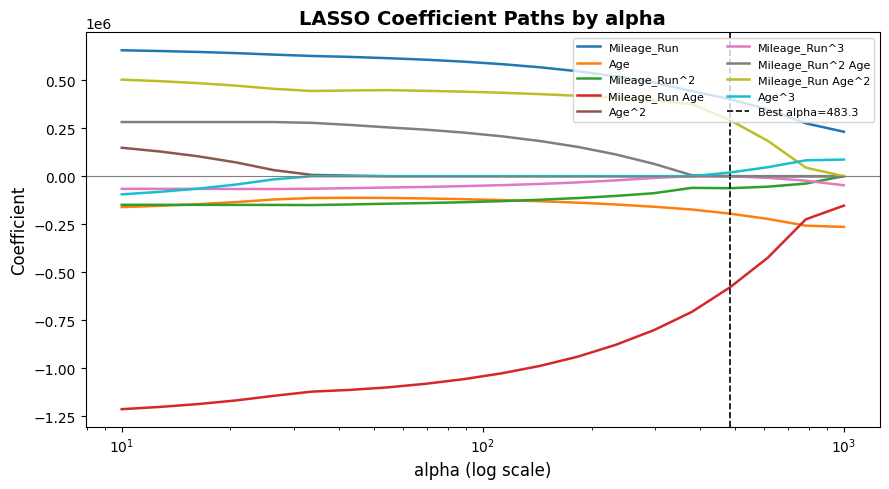

In [12]:
coef_paths = np.array([
    Lasso(alpha=a, max_iter=10000).fit(X_scaled, y).coef_
    for a in alphas
])
 
colors = plt.cm.tab10(np.linspace(0, 1, len(feat_names)))
fig, ax = plt.subplots(figsize=(9, 5))
for i, name in enumerate(feat_names):
    ax.plot(alphas, coef_paths[:, i], label=name, color=colors[i], linewidth=1.8)
ax.axvline(lasso_cv.alpha_, color="black", linestyle="--", linewidth=1.2,
           label=f"Best alpha={lasso_cv.alpha_:.1f}")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xscale("log")
ax.set_xlabel("alpha (log scale)", fontsize=12)
ax.set_ylabel("Coefficient", fontsize=12)
ax.set_title("LASSO Coefficient Paths by alpha", fontsize=14, fontweight="bold")
ax.legend(fontsize=8, loc="upper right", ncol=2)
plt.tight_layout()
plt.savefig("coef_paths.png", dpi=150)
plt.show()

6. Which features are actually selected? What proportion are set equal to zero?

In [ ]:
lasso_coef = pd.Series(lasso_cv.coef_, index=feat_names)
selected   = lasso_coef[lasso_coef != 0]
zeroed     = lasso_coef[lasso_coef == 0]
 
print(f"\nSelected ({len(selected)}):\n{selected.round(2)}")
print(f"\nZeroed ({len(zeroed)}): {list(zeroed.index)}")
print(f"Proportion zero: {len(zeroed)/len(lasso_coef):.2%}")


Selected (6):
Mileage_Run          401025.26
Age                 -194803.12
Mileage_Run^2        -62539.29
Mileage_Run Age     -578788.66
Mileage_Run Age^2    292015.03
Age^3                 19133.91
dtype: float64

Zeroed (3): ['Age^2', 'Mileage_Run^3', 'Mileage_Run^2 Age']
Proportion zeroed: 33.33%



7. Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign?

In [20]:
compare = pd.DataFrame({
    "OLS":   ols.coef_.round(2),
    "LASSO": lasso_cv.coef_.round(2)
}, index=feat_names)
compare["magnitude_increase"] = compare["LASSO"].abs() > compare["OLS"].abs()
compare["sign_change"] = np.sign(compare["OLS"]) != np.sign(compare["LASSO"])
 
print("\nOLS vs LASSO:\n", compare)


OLS vs LASSO:
                           OLS      LASSO  magnitude_increase  sign_change
Mileage_Run         668616.52  401025.26               False        False
Age                -184194.15 -194803.12                True        False
Mileage_Run^2      -149467.87  -62539.29               False        False
Mileage_Run Age   -1251592.34 -578788.66               False        False
Age^2               215639.88      -0.00               False         True
Mileage_Run^3       -65144.90      -0.00               False         True
Mileage_Run^2 Age   283339.15       0.00               False         True
Mileage_Run Age^2   528082.86  292015.03               False        False
Age^3              -138937.03   19133.91               False         True


Only Age increased in magnitude. Age^2, Mileage_run^3, Mileage_run^2, and Age^3 all had a sign change. However the first three were zeroed out so the real only sign change was Age^3. This tells us that the OLS for Age^3 was unstable and LASSO corrected it by shrinking it heavily toward 0 and flipping it. 

**Q3.** This is a case study on regularization.

1. Import the `heart_failure_clinical_records_dataset.csv` dataset. Use `PolynomialFeatures` to create a third-degree expansion of `age`, `ejection_fraction`, and `serum_creatinine`, and then use `StandardScaler` to $z$-score normalize your results. Use `PolynomialFeatures` with `interaction_only=True` to interact the dummy/categorical variables `anaemia`, `diabetes`, `high_blood_pressure`, and `smoking`. Concatenate these results into your feature/covariate matrix.
2. Use your features, run linear regression. Are there any sign patterns that appear counterintuitive? Why? Can you see how the inclusion of higher-order powers or interactions might resolve the apparent contradiction?
3. Use `LassoCV` to regularize your linear regression, using 20-fold cross validation. (Hint: I used the grid `alphas = np.logspace(-5,5,30)` to find the cost parameter)
4. Plot the cross-validated MSE by $\alpha$.
5. Plot the coefficient paths by $\alpha$.
6. Which features are actually selected? What proportion are set equal to zero? Compare the linear regressions and optimally regularized coefficients. Do any coefficients increase in magnitude from linear regression to LASSO? Do any change sign? Do the sign patterns for the linear_model or the Lasso seem to make more sense? Explain why this might be the case from the perspective of the bias-variance trade-off.

**Q4.** To better understand the math of regularization, we'll solve the regularized linear model problem with a single explanatory variable. So, the model is
$$
\tilde{y}_i = \tilde{b}_0 + \tilde{b}_1 \tilde{x}_i,
$$
where
$$
\tilde{y}_i = y_i - \bar{y} \quad \text{ and } \quad \tilde{x}_i = x_i - \bar{x}.
$$

Recall, we do this mean-normalization of $x$ and $y$, because
$$
\frac{1}{n} \sum_{i=1}^n \tilde{y} = \frac{1}{n} \sum_{i=1}^n y_i - \bar{y} = 0,
$$
and likewise for $x$. This trick makes the calculations easier and the results more easily interpretable.

1. To do ridge regression, add a penalty $+ \alpha (b_1)^2$ to mean squared error. What is the objective function for this problem?
2. Take the derivatives of your objective function with respect to $b_0$ and $b_1$. Set these equations equal to zero. Solve the two equations in two unknowns for $b_1$ and $b_0$.
3. How does increasing $\alpha$ change the slope coefficient?
4. If we instead used the LASSO/L1 penalty, $+\alpha |b_1|$, what challenge do you run into? This is conceptually difficult, but take 5 minutes and try to figure out the solution, and in particular, when is it optimal to set $b_1=0$?